# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [ ]:
import pandas as pd


In [ ]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [ ]:
orders.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [ ]:
catalog.head(10)

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [ ]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


**en df catalogo no hay nulls**

In [ ]:
marketing.head()

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


In [ ]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas

---

In [ ]:
orders["fecha_hora_pedido"]= pd.to_datetime(orders["fecha_hora_pedido"], errors="coerce")
marketing["fecha"]= pd.to_datetime(marketing["fecha"], errors="coerce")

In [ ]:
orders.info()
#validamos que se ejecuto la correccion del tipo de dato de "object" a "datetime" para la columna fecha

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25100 non-null  object        
 1   id_usuario          25100 non-null  object        
 2   fecha_hora_pedido   25100 non-null  datetime64[ns]
 3   pais                24800 non-null  object        
 4   dispositivo         25080 non-null  object        
 5   fuente_referencia   25070 non-null  object        
 6   nombre_producto     25070 non-null  object        
 7   categoria_producto  25020 non-null  object        
 8   cantidad            25050 non-null  float64       
 9   precio_unitario     25050 non-null  float64       
 10  monto_descuento     25050 non-null  float64       
 11  monto_total         25100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.3+ MB


In [ ]:
orders["id_pedido"].duplicated().sum()

100

In [ ]:
duplicados = orders[orders["id_pedido"].duplicated(keep=False)]
duplicados.sort_values(by="id_pedido")

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
25023,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2.0,221.34,0.0,442.67
10082,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2.0,221.34,0.0,442.67
25037,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1.0,170.10,10.0,160.10
10709,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1.0,170.10,10.0,160.10
25065,order_10829,user_7697,2025-01-23,Argentina,mobile,social,Phone-Pro-128GB,Electronica,2.0,115.54,0.0,231.08
...,...,...,...,...,...,...,...,...,...,...,...,...
25048,order_8326,user_6177,2025-06-14,Argentina,mobile,organic,Vacuum-Pro-Black,Hogar,1.0,457.53,0.0,457.53
25043,order_8414,user_4073,2025-05-10,Colombia,mobile,social,Jacket-Winter-M,Moda,2.0,144.35,10.0,278.71
8414,order_8414,user_4073,2025-05-10,Colombia,mobile,social,Jacket-Winter-M,Moda,2.0,144.35,10.0,278.71
25056,order_974,user_3262,2025-05-04,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,2.0,268.58,5.0,532.16


In [ ]:
duplicados.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 200 entries, 734 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           200 non-null    object        
 1   id_usuario          200 non-null    object        
 2   fecha_hora_pedido   200 non-null    datetime64[ns]
 3   pais                200 non-null    object        
 4   dispositivo         200 non-null    object        
 5   fuente_referencia   200 non-null    object        
 6   nombre_producto     200 non-null    object        
 7   categoria_producto  200 non-null    object        
 8   cantidad            200 non-null    float64       
 9   precio_unitario     200 non-null    float64       
 10  monto_descuento     200 non-null    float64       
 11  monto_total         200 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 20.3+ KB


no existen valor NaN en los uplicados, procedemos a eliminar

In [ ]:
orders = orders.drop_duplicates(subset=["id_pedido"], keep="first") #eliminamos los duplicados de id_pedido ya que es debe ser unico, y dejarlo afecta a promedio y totales

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25000 non-null  object        
 1   id_usuario          25000 non-null  object        
 2   fecha_hora_pedido   25000 non-null  datetime64[ns]
 3   pais                24700 non-null  object        
 4   dispositivo         24980 non-null  object        
 5   fuente_referencia   24970 non-null  object        
 6   nombre_producto     24970 non-null  object        
 7   categoria_producto  24920 non-null  object        
 8   cantidad            24950 non-null  float64       
 9   precio_unitario     24950 non-null  float64       
 10  monto_descuento     24950 non-null  float64       
 11  monto_total         25000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.5+ MB


In [ ]:

datemin=min(orders['fecha_hora_pedido'])
datemax=max(orders['fecha_hora_pedido'])

print(datemin, datemax)


2025-01-01 00:00:00 2025-06-30 00:00:00


In [ ]:
orders['fecha_hora_pedido']=orders['fecha_hora_pedido'].dt.date

In [ ]:
datemin=min(orders['fecha_hora_pedido'])
datemax=max(orders['fecha_hora_pedido'])

print(datemin, datemax)


2025-01-01 2025-06-30


In [ ]:
orders['pais'].unique() # estandarizacion de datos


array(['Argentina', 'Mexico', 'Colombia', 'mexico', 'colombia',
       'argentina', nan], dtype=object)

In [ ]:

orders['pais']= orders['pais'].replace('mexico','Mexico')
orders['pais']= orders['pais'].replace('colombia','Colombia')
orders['pais']= orders['pais'].replace('argentina','Argentina')

In [ ]:
orders['pais'].unique()

array(['Argentina', 'Mexico', 'Colombia', nan], dtype=object)

In [ ]:
#como no hay forma de  relacionar el pais  para recuperarlo, se reclasifica los nulls como "no_identificado"
orders['pais']= orders['pais'].fillna("no_identificado")

In [ ]:
orders['dispositivo'].unique()

array(['desktop', 'mobile', nan], dtype=object)

In [ ]:
#como no hay forma de  relacionar el dispositivo  para recuperarlo, se reclasifica los nulls como "no_identificado
orders['dispositivo']= orders['dispositivo'].fillna("no_odentificado")

In [ ]:
orders["fuente_referencia"].unique()

array(['organic', 'paid_search', 'social', nan], dtype=object)

In [ ]:
#como no hay forma de  relacionar el f. referencia  para recuperarlo, se reclasifica los nulls como "no_identificado
orders['fuente_referencia']= orders['fuente_referencia'].fillna("no_odentificado")

completar las categorias y producto

In [ ]:
orders["nombre_producto"].unique()

array(['Jacket-Winter-M', 'Tablet-Standard-64GB', 'Blender-XL-Red',
       'Laptop-Gaming-16GB', 'Sneakers-Urban-42', 'Phone-Pro-128GB',
       'Vacuum-Pro-Black', nan], dtype=object)

In [ ]:
#como no podemos relacionar el producto faltante  reclasificaremos como no_definido"
orders["nombre_producto"]= orders["nombre_producto"].fillna("no_definido")

In [ ]:
orders.groupby(["categoria_producto", "nombre_producto"], dropna=False).size().reset_index(name="cantidad")

,categoria_producto,nombre_producto,cantidad
0,Electronica,Laptop-Gaming-16GB,2778
1,Electronica,Phone-Pro-128GB,2737
2,Electronica,Tablet-Standard-64GB,2764
3,Hogar,Blender-XL-Red,4176
4,Hogar,Vacuum-Pro-Black,4170
5,Moda,Jacket-Winter-M,4166
6,Moda,Sneakers-Urban-42,4129
7,NaN,Blender-XL-Red,3
8,NaN,Jacket-Winter-M,10
9,NaN,Laptop-Gaming-16GB,4


In [ ]:
orders.loc[(orders["categoria_producto"].isna())&(orders["nombre_producto"] == 'no_definido'), 'categoria_producto']= 'no_definido'

In [ ]:
def completar_categoria(df):
    categorias = {
        "Laptop-Gaming-16GB": "Electronica",
        "Phone-Pro-128GB": "Electronica",
        "Tablet-Standard-64GB": "Electronica",
        "Blender-XL-Red": "Hogar",
        "Vacuum-Pro-Black": "Hogar",
        "Jacket-Winter-M": "Moda",
        "Sneakers-Urban-42": "Moda"}

    df.loc[df["categoria_producto"].isna(), "categoria_producto"] = (
        df.loc[df["categoria_producto"].isna(), "nombre_producto"]
        .map(categorias))

    return df

In [ ]:
orders = completar_categoria(orders)

In [ ]:
orders.groupby(["categoria_producto", "nombre_producto"], dropna=False).size().reset_index(name="cantidad")

,categoria_producto,nombre_producto,cantidad
0,Electronica,Laptop-Gaming-16GB,2782
1,Electronica,Phone-Pro-128GB,2740
2,Electronica,Tablet-Standard-64GB,2769
3,Hogar,Blender-XL-Red,4179
4,Hogar,Vacuum-Pro-Black,4176
5,Moda,Jacket-Winter-M,4176
6,Moda,Sneakers-Urban-42,4148
7,no_definido,no_definido,30


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25000 non-null  object 
 1   id_usuario          25000 non-null  object 
 2   fecha_hora_pedido   25000 non-null  object 
 3   pais                25000 non-null  object 
 4   dispositivo         25000 non-null  object 
 5   fuente_referencia   25000 non-null  object 
 6   nombre_producto     25000 non-null  object 
 7   categoria_producto  25000 non-null  object 
 8   cantidad            24950 non-null  float64
 9   precio_unitario     24950 non-null  float64
 10  monto_descuento     24950 non-null  float64
 11  monto_total         25000 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.5+ MB


**hemos estandarizado y reclasificado columnas categoricas**

**convertimos los datos numericos negativos a positivos**

In [ ]:
orders[["cantidad","precio_unitario","monto_descuento","monto_total"]].sum()
#validamos los valores de las columnas numericas


cantidad             177522.00
precio_unitario     6471394.46
monto_descuento      112340.00
monto_total        51987462.26
dtype: float64

In [ ]:
columnas = ["cantidad", "precio_unitario", "monto_descuento", "monto_total"]
orders[columnas].lt(0).sum()
#validamos cuantos valores negativos == <-o

cantidad           4
precio_unitario    0
monto_descuento    0
monto_total        4
dtype: int64

In [ ]:
orders[columnas] = orders[columnas].abs()
orders[columnas].lt(0).sum()

cantidad           0
precio_unitario    0
monto_descuento    0
monto_total        0
dtype: int64

In [ ]:

orders[["pais","cantidad","precio_unitario","monto_descuento","monto_total"]].sum()
#validamos los nuevos valores de las columnas numericas


pais               ArgentinaMexicoArgentinaColombiaArgentinaMexic...
cantidad                                                    177532.0
precio_unitario                                           6471394.46
monto_descuento                                             112340.0
monto_total                                              51989756.86
dtype: object

**calcularemos el promedio del precio_unitario, con la media  del precio unitario por tipo de producto(nombre_producto), esto con el fin de evitar dropna y tener datos más completos para  calculos de profit**

In [ ]:
orders[orders["cantidad"].isna()][["pais","nombre_producto","cantidad","precio_unitario","monto_descuento","monto_total"]].reset_index()
#visualizar los NaN para re calcular y evitar "dropna"

,index,pais,nombre_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,74,Argentina,Sneakers-Urban-42,NaN,NaN,NaN,595.85
1,75,Colombia,Sneakers-Urban-42,NaN,NaN,NaN,458.15
2,76,Argentina,Laptop-Gaming-16GB,NaN,NaN,NaN,319.75
3,77,Argentina,Vacuum-Pro-Black,NaN,NaN,NaN,227.55
4,78,Argentina,Phone-Pro-128GB,NaN,NaN,NaN,432.39
5,79,Colombia,Sneakers-Urban-42,NaN,NaN,NaN,527.15
6,80,Mexico,Vacuum-Pro-Black,NaN,NaN,NaN,711.18
7,81,Mexico,Tablet-Standard-64GB,NaN,NaN,NaN,41.08
8,82,Colombia,Sneakers-Urban-42,NaN,NaN,NaN,431.55
9,83,Argentina,Sneakers-Urban-42,NaN,NaN,NaN,279.35


In [ ]:
nan_antes = orders["precio_unitario"].isna().sum()
print(nan_antes)

50


In [ ]:
orders["precio_unitario"] = orders.groupby("nombre_producto")["precio_unitario"].transform(
    lambda x: x.fillna(x.mean()).round(2))#asignacion de precio promedio por nombre de producto ,a los NaN

In [ ]:
nan_despues = orders["precio_unitario"].isna().sum()
print(nan_despues)

0


In [ ]:
orders[orders["cantidad"].isna()][["pais","nombre_producto","cantidad","precio_unitario","monto_descuento","monto_total"]].reset_index()

,index,pais,nombre_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,74,Argentina,Sneakers-Urban-42,NaN,257.23,NaN,595.85
1,75,Colombia,Sneakers-Urban-42,NaN,257.23,NaN,458.15
2,76,Argentina,Laptop-Gaming-16GB,NaN,261.36,NaN,319.75
3,77,Argentina,Vacuum-Pro-Black,NaN,261.02,NaN,227.55
4,78,Argentina,Phone-Pro-128GB,NaN,259.54,NaN,432.39
5,79,Colombia,Sneakers-Urban-42,NaN,257.23,NaN,527.15
6,80,Mexico,Vacuum-Pro-Black,NaN,261.02,NaN,711.18
7,81,Mexico,Tablet-Standard-64GB,NaN,257.53,NaN,41.08
8,82,Colombia,Sneakers-Urban-42,NaN,257.23,NaN,431.55
9,83,Argentina,Sneakers-Urban-42,NaN,257.23,NaN,279.35


**buscaremos recalcular la cantidad de  unidades NaN, dividiento el importe de "monto_total"/ "precio_unitario" por fila**

In [ ]:
nan_cantidad_antes = orders["cantidad"].isna().sum()
print(nan_cantidad_antes)

50


In [ ]:
orders["cantidad"] = orders["cantidad"].fillna(
    orders["monto_total"] / orders["precio_unitario"]
).round()

In [ ]:
nan_cantidad_despues = orders["cantidad"].isna().sum()
print(nan_cantidad_despues)


0


In [ ]:
orders[orders["monto_descuento"].isna()][["pais","nombre_producto","cantidad","precio_unitario","monto_descuento","monto_total"]].reset_index()

,index,pais,nombre_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,74,Argentina,Sneakers-Urban-42,2.0,257.23,NaN,595.85
1,75,Colombia,Sneakers-Urban-42,2.0,257.23,NaN,458.15
2,76,Argentina,Laptop-Gaming-16GB,1.0,261.36,NaN,319.75
3,77,Argentina,Vacuum-Pro-Black,1.0,261.02,NaN,227.55
4,78,Argentina,Phone-Pro-128GB,2.0,259.54,NaN,432.39
5,79,Colombia,Sneakers-Urban-42,2.0,257.23,NaN,527.15
6,80,Mexico,Vacuum-Pro-Black,3.0,261.02,NaN,711.18
7,81,Mexico,Tablet-Standard-64GB,0.0,257.53,NaN,41.08
8,82,Colombia,Sneakers-Urban-42,2.0,257.23,NaN,431.55
9,83,Argentina,Sneakers-Urban-42,1.0,257.23,NaN,279.35


**calcularemos el importe de descuento por diferencia de multiplicacion de cantida por precio unitario menos monto total**
*(cantida x precio)- monto total

In [ ]:
nan_descuento= orders["monto_descuento"].isna().sum()
print(nan_descuento)

50


In [ ]:
calculo_descuento = (orders["precio_unitario"] * orders["cantidad"]) - orders["monto_total"]
orders["monto_descuento"] = orders["monto_descuento"].fillna(calculo_descuento)

In [ ]:
nan_descuento_despues= orders["monto_descuento"].isna().sum()
print(nan_descuento_despues)

0


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25000 non-null  object 
 1   id_usuario          25000 non-null  object 
 2   fecha_hora_pedido   25000 non-null  object 
 3   pais                25000 non-null  object 
 4   dispositivo         25000 non-null  object 
 5   fuente_referencia   25000 non-null  object 
 6   nombre_producto     25000 non-null  object 
 7   categoria_producto  25000 non-null  object 
 8   cantidad            25000 non-null  float64
 9   precio_unitario     25000 non-null  float64
 10  monto_descuento     25000 non-null  float64
 11  monto_total         25000 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.5+ MB


**conseguimos estandarizar, reclasificar y recuperar los datos paar el analisis en "df orders" lo cual se logro**

-id_pedido se elimina los duplicados

-fecha se da el correcto formato de datetime64

-se corriguieron valores negativo

-pais,dispositivo, fuente_referencia y nombre de producto, no se puede recuperar por que no hay relacion que permita recuperar, se reclasifican como "no identificados"

-categoria_producto se asigna y se sustituye los nulls, por la categoria conforma a la relacion de nombre_producto

-se recalculan tomando como base monto total, precio unitario, cantidad, y monto descuento


In [ ]:
marketing.info()
#validamos que se ejecuto la correccion del tipo de dato de "object" a "datetime" para la columna fecha

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1519 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


In [ ]:

nan_canal_antes=marketing["canal"].isna().sum()
print("nan canal antes",nan_canal_antes)


nan canal antes 101


In [ ]:
marketing[marketing["canal"].isna()][["pais","canal","gasto"]]

,pais,canal,gasto
98,Argentina,NaN,849.70
99,Mexico,NaN,2033.56
100,Mexico,NaN,1260.65
101,Mexico,NaN,1660.90
102,Colombia,NaN,1819.27
...,...,...,...
194,Colombia,NaN,772.46
195,Argentina,NaN,1562.61
196,Argentina,NaN,644.34
197,Argentina,NaN,2544.66


In [ ]:
marketing["canal"]=marketing["canal"].fillna("canal_no_definido")

In [ ]:
nan_canal_despues=marketing["canal"].isna().sum()
print("nan canal despues",nan_canal_despues)

nan canal despues 0


In [ ]:
marketing["canal"].value_counts()

paid_search          507
organic              506
social               506
canal_no_definido    101
Name: canal, dtype: int64

In [ ]:
marketing["pais"].value_counts()

Colombia     540
Argentina    540
Mexico       540
Name: pais, dtype: int64

**df marketing, no hay relacion que permita sustituir los nulls de "canal", por lo cual se reclasifican como "no identificado"

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

In [ ]:
#realizaremos la asignacion de costo unitario del producto para poder calcular un estimado de costo total. ya que no se puede recuperar el nombre del producto para lograra asignar precio unitario
orders_join = orders.merge(catalog, on="nombre_producto", how="inner")

In [ ]:
orders_join.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto_x,cantidad,precio_unitario,monto_descuento,monto_total,categoria_producto_y,costo_unitario,proveedor
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37,Moda,189.31,Mcmillan-Rhodes
1,order_12,user_6810,2025-03-17,Colombia,mobile,social,Jacket-Winter-M,Moda,1.0,499.48,5.0,494.48,Moda,189.31,Mcmillan-Rhodes
2,order_13,user_3170,2025-04-10,Colombia,desktop,organic,Jacket-Winter-M,Moda,1.0,496.94,0.0,496.94,Moda,189.31,Mcmillan-Rhodes
3,order_15,user_1500,2025-04-03,Colombia,mobile,organic,Jacket-Winter-M,Moda,2.0,373.47,0.0,746.94,Moda,189.31,Mcmillan-Rhodes
4,order_19,user_7190,2025-02-03,Argentina,mobile,social,Jacket-Winter-M,Moda,2.0,45.86,0.0,91.72,Moda,189.31,Mcmillan-Rhodes


In [ ]:
ingresos_totales= orders["monto_total"].sum().round()
print("Ingresos Totales:",ingresos_totales)

Ingresos Totales: 51989757.0


In [ ]:
costo_total= orders_join["costo_unitario"]*orders_join["cantidad"]
costo_total_productos=costo_total.sum().round()
por_productos= (costo_total_productos*100/ingresos_totales).round(2)
print("Costo total de productos vendidos:",costo_total_productos, )
print("%/ingresos:",por_productos)


Costo total de productos vendidos: 43131278.0
%/ingresos: 82.96


In [ ]:
publicidad=marketing["gasto"].sum()
por_publicidad= (publicidad*100/ingresos_totales).round(2)
print("importe de inversion en Marketing:",publicidad)
print("%/ingresos:",por_publicidad)

importe de inversion en Marketing: 2871843.53
%/ingresos: 5.52


In [ ]:
costo_total= costo_total_productos+publicidad
por_costo_total=(costo_total*100/ingresos_totales)
print("Costo Total:",costo_total.round())
print("%/ingresos:",por_costo_total)

Costo Total: 46003122.0
%/ingresos: 88.48497124154667


In [ ]:
profit=(ingresos_totales-costo_total).round(2)
porcentaje= (profit*100/ingresos_totales).round(2)
print("profit:",profit)
print("% de profit:",porcentaje)



profit: 5986635.47
% de profit: 11.52


In [ ]:
print("Tiket Promedio:", orders["monto_total"].mean().round(2))
print("promedio de productos vendidos por tiket:", orders["cantidad"].mean())

Tiket Promedio: 2079.59
promedio de productos vendidos por tiket: 7.10468


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
orders["nombre_producto"].value_counts().sort_values(ascending=False)


Blender-XL-Red          4179
Vacuum-Pro-Black        4176
Jacket-Winter-M         4176
Sneakers-Urban-42       4148
Laptop-Gaming-16GB      2782
Tablet-Standard-64GB    2769
Phone-Pro-128GB         2740
no_definido               30
Name: nombre_producto, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

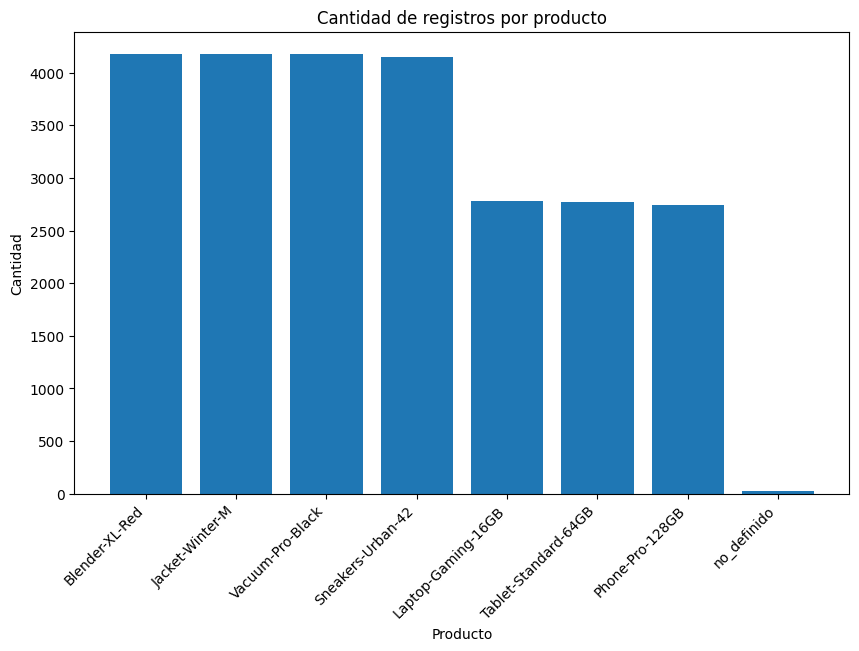

In [ ]:
import matplotlib.pyplot as plt
productos = [
    'Blender-XL-Red',
    'Jacket-Winter-M',
    'Vacuum-Pro-Black',
    'Sneakers-Urban-42',
    'Laptop-Gaming-16GB',
    'Tablet-Standard-64GB',
    'Phone-Pro-128GB',
    'no_definido'
]

cantidades = [4179, 4176, 4176, 4148, 2782, 2769, 2740, 30]

plt.figure(figsize=(10, 6))

barras = plt.bar(productos, cantidades)

plt.title('Cantidad de registros por producto')
plt.xlabel('Producto')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')


el gráfico de barras muestra el comparativo de conteo de unidades vendidas durante el perido donde el producto más vendido: **Blender-XL-Red con 4179 unidades**

In [ ]:

def sumar_por_canal (marketing):
      return marketing.groupby("canal")["gasto"].sum().sort_values(ascending=False)
print(sumar_por_canal(marketing))
print("gasto por canal")


canal
social               918043.21
organic              913533.01
paid_search          863088.21
canal_no_definido    177179.10
Name: gasto, dtype: float64
gasto por canal


([0, 1, 2, 3],
 [Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')])

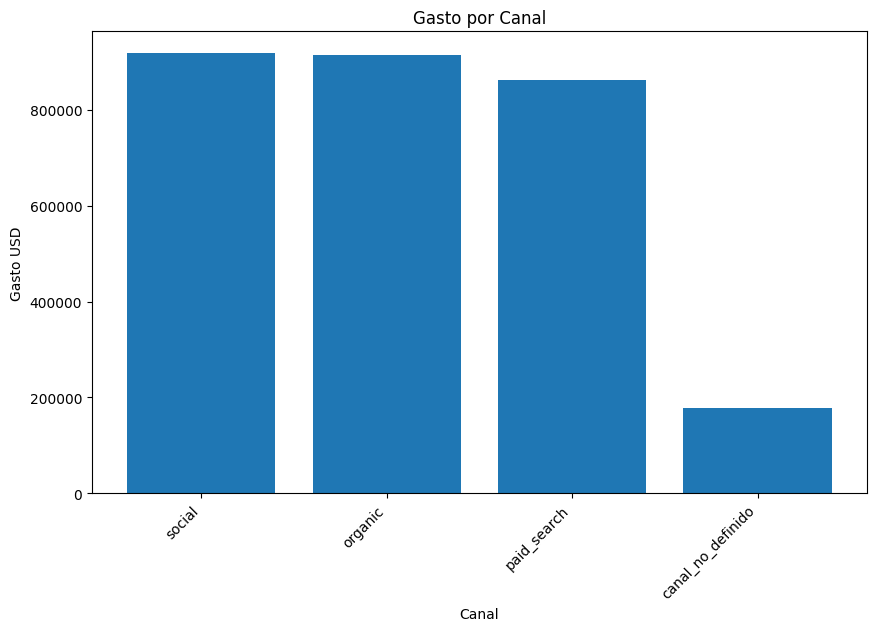

In [ ]:

import matplotlib.pyplot as plt

canal = [
    'social',
    'organic',
    'paid_search',
    'canal_no_definido']

gasto = [918043.21, 913533.01, 863088.21, 177179.10]

plt.figure(figsize=(10, 6))

barras = plt.bar(canal, gasto)

plt.title('Gasto por Canal')
plt.xlabel('Canal')
plt.ylabel('Gasto USD')
plt.xticks(rotation=45, ha='right')

el gráfico de barra muestra los importes de ingresos que se generan  por cada unos de los cales de venta donde **el canal SOCIAL es el medio con mayor desempeño en generar ingresos**

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [ ]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT  nombre_evento,
        COUNT(DISTINCT id_usuario) conteo_unico_usuario
FROM events
GROUP BY nombre_evento
ORDER BY conteo_unico_usuario DESC;
'''
totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,conteo_unico_usuario
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [ ]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''

SELECT   COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
'''


totals = pd.read_sql(query_totals, con=engine)
totals

,usuarios_unicos
0,8000


son 8000 usuarios unicos, pero solo 7796 hacen el recorrido desde el inicio teneindo una diferencia de 204 los cuales pueden ser posibles errores o usuarios que ingresaron de forma directa  en algún paso espeficico del proceso de compra

In [ ]:
# PARTE 1: Totales del funnel
# ======================
query_totals = '''


WITH cte_primera_visita AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento ='first_visit'),

cte_seleccion_item AS (SELECT DISTINCT id_usuario

    FROM events

    WHERE nombre_evento = 'select_item'),

cte_add_to_cart AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_to_cart'),

cte_checkout AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'begin_checkout'),

cte_payment_info AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'),

cte_purchase AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase')

SELECT
COUNT(DISTINCT pv.id_usuario) AS first_visit,
COUNT(DISTINCT si.id_usuario) AS select_item,
COUNT(DISTINCT ac.id_usuario) AS add_to_cart,
COUNT(DISTINCT ck.id_usuario) AS begin_checkout,
COUNT(DISTINCT pi.id_usuario) AS add_payment_info,
COUNT(DISTINCT p.id_usuario) AS purchase


FROM cte_primera_visita AS pv
LEFT JOIN cte_seleccion_item AS si ON pv.id_usuario =si.id_usuario
LEFT JOIN cte_add_to_cart AS ac ON  si.id_usuario = ac.id_usuario

LEFT JOIN cte_checkout AS ck ON ac.id_usuario = ck.id_usuario
LEFT JOIN cte_payment_info AS pi ON ck.id_usuario = pi.id_usuario

LEFT JOIN cte_purchase AS p ON pi.id_usuario = p.id_usuario;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,first_visit,select_item,add_to_cart,begin_checkout,add_payment_info,purchase
0,7796,7393,7052,6364,4967,3857


podemos visualizar el conteo de los usuarios que realizaron el ciclo de compra desde el primer paso, esto para validar la efectividad de la pagina. ya que se detecta en varios  pasos que diversos usuarios entran desde pasos posteriores a "first_vist"  creando la inconsistencia de no realizar todo el recorrido. como el objeto de estudio es analizar el recorrido  de ususrio  del "funnel"  de ventas que prmite validar la efectividad de retencion de comprador que tiene la pagina.

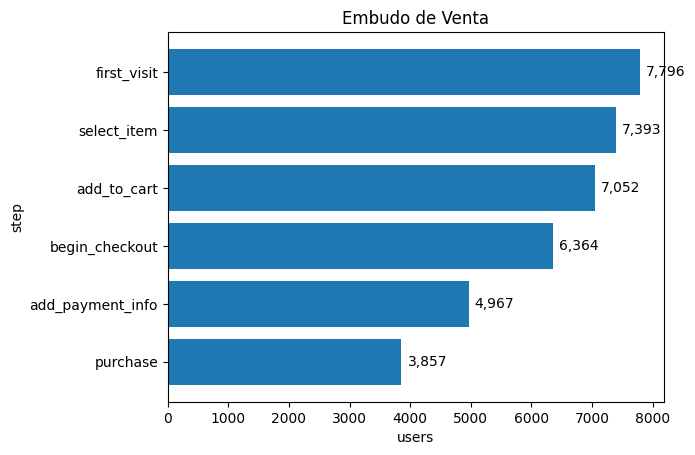

In [ ]:
import matplotlib.pyplot as plt

step= ['first_visit', 'select_item', 'add_to_cart', 'begin_checkout', 'add_payment_info', 'purchase']

users= [7796, 7393, 7052, 6364, 4967, 3857]

step = step[::-1]
users = users[::-1]


plt.barh(step, users)
for i, usuario in enumerate(users):
    plt.text(
        usuario + 100,
        i,
        f'{usuario:,}',
        va='center'
    )

plt.xlabel('users')
plt.ylabel('step')
plt.title("Embudo de Venta")
plt.show()

representacion gráfica del proce de conversion de compra de los usuarios. el cual se muestra de forma correcta, ya que no hay saltos draticos entre etapas,

si hubiera  enchanzamiento o datos lineales se debe revisar el paso en donde se presenta la situacion

In [ ]:
# PARTE 1: Totales del funnel
# ======================
query_totals = '''


WITH cte_primera_visita AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento ='first_visit'),

cte_seleccion_item AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'select_item'),

cte_add_to_cart AS (SELECT DISTINCT id_usuario
    FROM events

    WHERE nombre_evento = 'add_to_cart'),

cte_checkout AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'begin_checkout'),

cte_payment_info AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'),

cte_purchase AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase')

SELECT

ROUND(COUNT(DISTINCT p.id_usuario)*100.0/NULLIF(COUNT(DISTINCT pv.id_usuario), 0),2) AS eficiencia_funnel_de_venta

FROM cte_primera_visita AS pv
LEFT JOIN cte_seleccion_item AS si ON pv.id_usuario =si.id_usuario
LEFT JOIN cte_add_to_cart AS ac ON  si.id_usuario = ac.id_usuario
LEFT JOIN cte_checkout AS ck ON ac.id_usuario = ck.id_usuario
LEFT JOIN cte_payment_info AS pi ON ck.id_usuario = pi.id_usuario
LEFT JOIN cte_purchase AS p ON pi.id_usuario = p.id_usuario;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,eficiencia_funnel_de_venta
0,49.47


calcularemos  abandono

In [ ]:
query_totals = '''


WITH cte_primera_visita AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento ='first_visit'),

cte_seleccion_item AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'select_item'),

cte_add_to_cart AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_to_cart'),

cte_checkout AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'begin_checkout'),

cte_payment_info AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'),

cte_purchase AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase')

SELECT
COUNT(DISTINCT pv.id_usuario) - COUNT(DISTINCT si.id_usuario) AS dropoff_select_item,
COUNT(DISTINCT si.id_usuario) - COUNT(DISTINCT ac.id_usuario) AS dropoff_add_to_cart,
COUNT(DISTINCT ac.id_usuario) - COUNT(DISTINCT ck.id_usuario) AS dropoff_begin_checkout,
COUNT(DISTINCT ck.id_usuario) - COUNT(DISTINCT pi.id_usuario) AS dropoff_add_payment_info,
COUNT(DISTINCT pi.id_usuario) - COUNT(DISTINCT p.id_usuario)  AS dropoff_purchase


FROM cte_primera_visita AS pv
LEFT JOIN cte_seleccion_item AS si ON pv.id_usuario =si.id_usuario
LEFT JOIN cte_add_to_cart AS ac ON  si.id_usuario = ac.id_usuario
LEFT JOIN cte_checkout AS ck ON ac.id_usuario = ck.id_usuario
LEFT JOIN cte_payment_info AS pi ON ck.id_usuario = pi.id_usuario
LEFT JOIN cte_purchase AS p ON pi.id_usuario = p.id_usuario;
'''

totals_dropoff = pd.read_sql(query_totals, con=engine)
totals_dropoff

,dropoff_select_item,dropoff_add_to_cart,dropoff_begin_checkout,dropoff_add_payment_info,dropoff_purchase
0,403,341,688,1397,1110


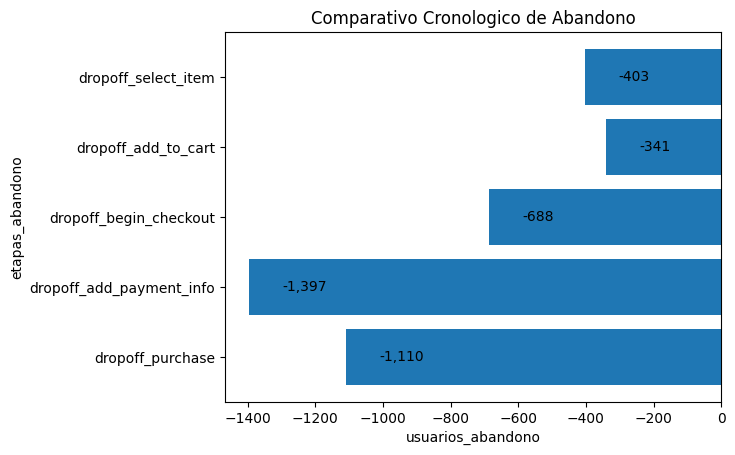

In [ ]:
import matplotlib.pyplot as plt
step_off =['dropoff_select_item', 'dropoff_add_to_cart', 'dropoff_begin_checkout', 'dropoff_add_payment_info','dropoff_purchase']
users_off= [ -403, -341, -688, -1397, -1110]


etapas_abandono = step_off[::-1]
usuarios_abandono = users_off[::-1]

plt.barh(etapas_abandono, usuarios_abandono)
for i, usuario in enumerate(usuarios_abandono):
    plt.text(
        usuario + 100,
        i,
        f'{usuario:,}',
        va='center'
    )


plt.xlabel('usuarios_abandono')
plt.ylabel('etapas_abandono')
plt.title("Comparativo Cronologico de Abandono")
plt.show()


el gráfico muestra el comparativo de abandono de usuarios en en referencia a la etapa anterior: de first_visit a select_item se perdieron -403 usuarios entre estas 2 etapas
entre select_item y add_to cart se perdierob -341 usuarios.... y en consecutivo,  visualizamos que el mayor numero de usuarios que se perdieron fue entre el pso begin_checkout y add_payment_info con -1397, importante validar si existe  situaciones de plataforma que esten generando abandono al momento de pagar eje: puede ser que sea muy complejo o muy engorrozo conluir el proceso de informacion de pago.

calculo de tasa de conversion

In [ ]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH cte_primera_visita AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento ='first_visit'),

cte_seleccion_item AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'select_item'),

cte_add_to_cart AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_to_cart'),

cte_checkout AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'begin_checkout'),


cte_payment_info AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'),

cte_purchase AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase')

SELECT

ROUND((COUNT(DISTINCT si.id_usuario)) * 100.0 / NULLIF(COUNT(DISTINCT pv.id_usuario),0),2) AS select_item_pct_conv,
ROUND((COUNT(DISTINCT ac.id_usuario)) * 100.0 / NULLIF(COUNT(DISTINCT si.id_usuario),0),2) AS add_to_cart_pct_conv,
ROUND((COUNT(DISTINCT ck.id_usuario)) * 100.0 / NULLIF(COUNT(DISTINCT ac.id_usuario),0),2) AS begin_checkout_pct_conv,
ROUND((COUNT(DISTINCT pi.id_usuario)) * 100.0 / NULLIF(COUNT(DISTINCT ck.id_usuario),0),2) AS add_payment_info_pct_conv,
ROUND((COUNT(DISTINCT p.id_usuario)) * 100.0 / NULLIF(COUNT(DISTINCT pi.id_usuario),0),2) AS purchase_pct_conv

FROM cte_primera_visita AS pv
LEFT JOIN cte_seleccion_item AS si ON pv.id_usuario =si.id_usuario
LEFT JOIN cte_add_to_cart AS ac ON  si.id_usuario = ac.id_usuario
LEFT JOIN cte_checkout AS ck ON ac.id_usuario = ck.id_usuario
LEFT JOIN cte_payment_info AS pi ON ck.id_usuario = pi.id_usuario
LEFT JOIN cte_purchase AS p ON pi.id_usuario = p.id_usuario;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,select_item_pct_conv,add_to_cart_pct_conv,begin_checkout_pct_conv,add_payment_info_pct_conv,purchase_pct_conv
0,94.83,95.39,90.24,78.05,77.65


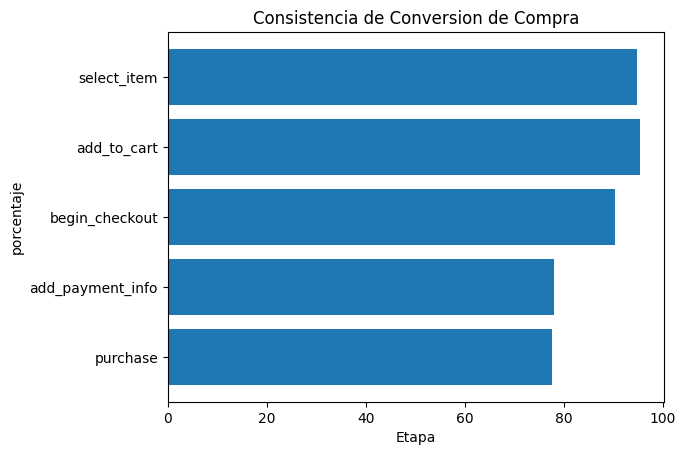

In [ ]:

import matplotlib.pyplot as plt

etapa = ['select_item', 'add_to_cart', 'begin_checkout','add_payment_info','purchase']

porcentaje_conversion= [ 94.83, 95.39, 90.24, 78.05, 77.65]

etapa=etapa[::-1]
porcentaje_conversion= porcentaje_conversion[::-1]
plt.barh(etapa, porcentaje_conversion)




plt.xlabel('Etapa')
plt.ylabel('porcentaje')
plt.title('Consistencia de Conversion de Compra')


plt.show()


El gráfico muestra la tasa de conversion la cual marca la  consistencia porcentual de conversion entre etapas ( **una comparativa antre una etapa anterior**)

In [ ]:
query_conversion = '''

WITH cte_primera_visita AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento ='first_visit'),

cte_seleccion_item AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'select_item'),

cte_add_to_cart AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_to_cart'),

cte_checkout AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'begin_checkout'),

cte_payment_info AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'),

cte_purchase AS (SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase')

SELECT

ROUND((COUNT(DISTINCT pv.id_usuario) - COUNT(DISTINCT si.id_usuario)) * 100.0 / NULLIF(COUNT(DISTINCT pv.id_usuario),0),2) AS dropoff_select_item_pct,
ROUND((COUNT(DISTINCT si.id_usuario) - COUNT(DISTINCT ac.id_usuario)) * 100.0 / NULLIF(COUNT(DISTINCT si.id_usuario),0),2) AS dropoff_add_to_cart_PCT,
ROUND((COUNT(DISTINCT ac.id_usuario) - COUNT(DISTINCT ck.id_usuario)) * 100.0 / NULLIF(COUNT(DISTINCT ac.id_usuario),0),2) AS dropoff_begin_checkout_pct,
ROUND((COUNT(DISTINCT ck.id_usuario) - COUNT(DISTINCT pi.id_usuario)) * 100.0 / NULLIF(COUNT(DISTINCT ck.id_usuario),0),2) AS dropoff_add_payment_info_pct,
ROUND((COUNT(DISTINCT pi.id_usuario) - COUNT(DISTINCT p.id_usuario)) * 100.0 / NULLIF(COUNT(DISTINCT p.id_usuario),0),2) AS dropoff_purchase_pct


FROM cte_primera_visita AS pv
LEFT JOIN cte_seleccion_item AS si ON pv.id_usuario =si.id_usuario
LEFT JOIN cte_add_to_cart AS ac ON  si.id_usuario = ac.id_usuario
LEFT JOIN cte_checkout AS ck ON ac.id_usuario = ck.id_usuario
LEFT JOIN cte_payment_info AS pi ON ck.id_usuario = pi.id_usuario
LEFT JOIN cte_purchase AS p ON pi.id_usuario = p.id_usuario;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,dropoff_select_item_pct,dropoff_add_to_cart_pct,dropoff_begin_checkout_pct,dropoff_add_payment_info_pct,dropoff_purchase_pct
0,5.17,4.61,9.76,21.95,28.78


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free
3,user_3,2025-03-04,Mexico,desktop,free
4,user_4,2025-02-27,Argentina,desktop,free
...,...,...,...,...,...
7995,user_7995,2025-05-16,Argentina,mobile,free
7996,user_7996,2025-01-05,Colombia,mobile,free
7997,user_7997,2025-04-19,Mexico,desktop,free
7998,user_7998,2025-05-28,Colombia,desktop,free


In [ ]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1
3,user_0,2025-02-26,28,0
4,user_1,2025-01-14,7,0
...,...,...,...,...
31995,user_7998,2025-06-25,28,1
31996,user_7999,2025-03-29,7,0
31997,user_7999,2025-04-05,14,1
31998,user_7999,2025-04-12,21,0


In [ ]:
# Retención por cohortes
# agrupacion de usuarios a su cohorte  correspondiente ======================

query_cohort_retention_final = '''
SELECT id_usuario, DATE_TRUNC('month', MIN(CAST(fecha_registro AS DATE))) AS cohorte_mes
FROM users
GROUP BY id_usuario;

'''


# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,id_usuario,cohorte_mes
0,user_3160,2025-01-01 00:00:00+00:00
1,user_5838,2025-01-01 00:00:00+00:00
2,user_6035,2025-05-01 00:00:00+00:00
3,user_7849,2025-05-01 00:00:00+00:00
4,user_1361,2025-03-01 00:00:00+00:00
...,...,...
7995,user_5752,2025-01-01 00:00:00+00:00
7996,user_7298,2025-05-01 00:00:00+00:00
7997,user_3286,2025-01-01 00:00:00+00:00
7998,user_107,2025-05-01 00:00:00+00:00


In [ ]:
# Retención por cohortes
# agrupacion de usuarios a su cohorte  correspondiente ======================

query_cohort_retention_final = '''

WITH cohorte AS (SELECT id_usuario, DATE_TRUNC('month', MIN(CAST(fecha_registro AS DATE))) AS cohorte_mes

FROM users
GROUP BY id_usuario),

conteo_usuarios AS (SELECT cohorte_mes,
        COUNT(DISTINCT id_usuario) AS clientes_iniciales
FROM cohorte
GROUP BY cohorte_mes)
SELECT *
FROM conteo_usuarios
ORDER BY cohorte_mes;

'''


# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte_mes,clientes_iniciales
0,2025-01-01 00:00:00+00:00,1627
1,2025-02-01 00:00:00+00:00,1444
2,2025-03-01 00:00:00+00:00,1636
3,2025-04-01 00:00:00+00:00,1606
4,2025-05-01 00:00:00+00:00,1687


In [ ]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''

WITH cohorte AS (SELECT id_usuario, DATE_TRUNC('month', MIN(CAST(fecha_registro AS DATE))) AS cohorte_mes

FROM users
GROUP BY id_usuario),

retenciones AS (SELECT TO_CHAR(c.cohorte_mes, 'YYYY-MM') AS cohorte_mes ,
        COUNT(DISTINCT c.id_usuario) AS clientes_iniciales,
        COUNT(CASE WHEN ua.dias_despues_registro >=1 AND ua.dias_despues_registro <=7 AND ua.activo = 1 THEN ua.id_usuario END) AS semana1,
        COUNT(CASE WHEN ua.dias_despues_registro >7 AND ua.dias_despues_registro <=14 AND ua.activo = 1 THEN  ua.id_usuario END) AS semana2,
        COUNT(CASE WHEN ua.dias_despues_registro >14 AND ua.dias_despues_registro <=28 AND ua.activo = 1 THEN ua.id_usuario END) AS semana3,
        COUNT(CASE WHEN ua.dias_despues_registro >28 AND ua.activo = 1 THEN ua.id_usuario END) AS semana4
FROM cohorte AS c
LEFT JOIN user_activity AS ua ON c.id_usuario = ua.id_usuario
GROUP BY cohorte_mes)

SELECT cohorte_mes, clientes_iniciales, semana1, semana2, semana3, semana4
FROM retenciones

'''


# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte_mes,clientes_iniciales,semana1,semana2,semana3,semana4
0,2025-01,1627,697,668,1327,0
1,2025-02,1444,611,609,1210,0
2,2025-03,1636,677,705,1363,0
3,2025-04,1606,680,697,1315,0
4,2025-05,1687,695,676,1385,0


In [ ]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''



WITH cohorte AS (SELECT id_usuario, DATE_TRUNC('month', MIN(CAST(fecha_registro AS DATE))) AS cohorte_mes

FROM users
GROUP BY id_usuario),

retenciones AS (SELECT TO_CHAR(c.cohorte_mes, 'YYYY-MM') AS cohorte_mes,
        ROUND(COUNT(CASE WHEN ua.dias_despues_registro >1 AND ua.dias_despues_registro <=7 AND ua.activo = 1 THEN 1 END) *100.0 / COUNT(DISTINCT ua.id_usuario),2)AS tasa_retencion_semana1,
        ROUND(COUNT(CASE WHEN ua.dias_despues_registro >7 AND ua.dias_despues_registro <=14 AND ua.activo = 1 THEN 1 END) *100.0/ COUNT(DISTINCT ua.id_usuario),2) AS tasa_retencion_semana2,
        ROUND(COUNT(CASE WHEN ua.dias_despues_registro >14 AND ua.dias_despues_registro <=28 AND ua.activo = 1 THEN 1 END) * 100.0 /COUNT(DISTINCT ua.id_usuario),2) AS tasa_retencion_semana3,
        ROUND(COUNT(CASE WHEN ua.dias_despues_registro >28 AND ua.activo = 1 THEN 1 END) *100 / COUNT(DISTINCT ua.id_usuario),2) AS tasa_retencion_semana4
FROM cohorte AS c
LEFT JOIN user_activity AS ua ON c.id_usuario = ua.id_usuario
GROUP BY cohorte_mes)

SELECT cohorte_mes, tasa_retencion_semana1, tasa_retencion_semana2, tasa_retencion_semana3, tasa_retencion_semana4
FROM retenciones

'''


# Ejecutar la consulta
cohorte_final_ppc = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final_ppc

,cohorte_mes,tasa_retencion_semana1,tasa_retencion_semana2,tasa_retencion_semana3,tasa_retencion_semana4
0,2025-01,42.84,41.06,81.56,0.0
1,2025-02,42.31,42.17,83.80,0.0
2,2025-03,41.38,43.09,83.31,0.0
3,2025-04,42.34,43.40,81.88,0.0
4,2025-05,41.20,40.07,82.10,0.0


In [ ]:


cohorte_final_ppc_index =cohorte_final_ppc.set_index('cohorte_mes')
print(cohorte_final_ppc_index)






             tasa_retencion_semana1  tasa_retencion_semana2  \
cohorte_mes                                                   
2025-01                       42.84                   41.06   
2025-02                       42.31                   42.17   
2025-03                       41.38                   43.09   
2025-04                       42.34                   43.40   
2025-05                       41.20                   40.07   

             tasa_retencion_semana3  tasa_retencion_semana4  
cohorte_mes                                                  
2025-01                       81.56                     0.0  
2025-02                       83.80                     0.0  
2025-03                       83.31                     0.0  
2025-04                       81.88                     0.0  
2025-05                       82.10                     0.0  


In [ ]:
import matplotlib.pyplot as plt

import seaborn as sns


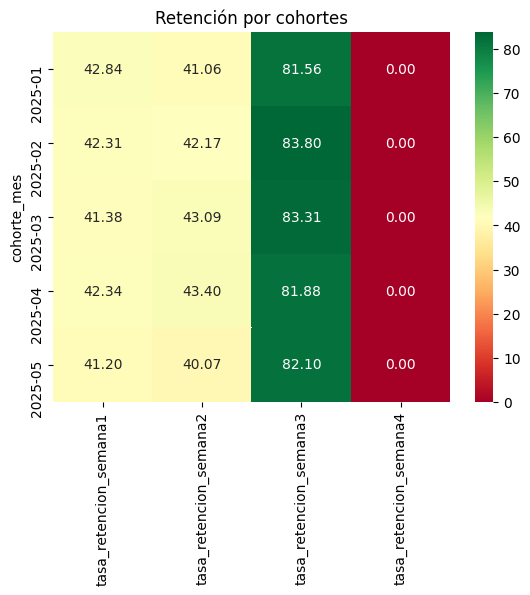

In [ ]:

sns.heatmap(cohorte_final_ppc_index, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Retención por cohortes")
plt.show()


**se logra visualizar que todas las cohortes tienen un repunte de retencion  en la 3er semana, pero a la 4ta estos caen de forma drastica**

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

---
Hipótesis estadística

   - **H₀ (Hipótesis nula):** No existe diferencia en la tasa de conversión entre las variantes.
   - **H₁ (Hipótesis alternativa):** Existe una diferencia en la tasa de conversión entre las variantes.

  
**Test estadístico:** Z-test

**Nivel de significancia alpha:** 0.05


In [ ]:
# tu código aquí
exp = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
from statsmodels.stats.proportion import proportions_ztest


In [ ]:
exp.head()

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [ ]:
exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [ ]:
print("tamaño de muestra, por variante ")
totales= exp.groupby("variante")['convirtio'].count()
print(totales)


tamaño de muestra, por variante 
variante
control        4965
tratamiento    5035
Name: convirtio, dtype: int64


In [ ]:
print("conteo de conversion por variante")
conversiones =exp.groupby("variante")['convirtio'].sum()
print(conversiones)

conteo de conversion por variante
variante
control        779
tratamiento    820
Name: convirtio, dtype: int64


In [ ]:
print("tasa de conversion de variante")
print(round(conversiones *100/ totales))

tasa de conversion de variante
variante
control        16.0
tratamiento    16.0
Name: convirtio, dtype: float64


In [ ]:
df_tratamiento= exp[(exp['variante']== 'tratamiento') & (exp['convirtio']==1)]
df_control= exp[(exp['variante']== "control") & (exp["convirtio"]==1)]
print("creamos df independiente para cada uno de las versiones control y tratamiento")
print()
print("TRATAMIEENTO")
print(df_tratamiento.head())
print()
print("CONTROL")
print(df_control.head())

creamos df independiente para cada uno de las versiones control y tratamiento

TRATAMIEENTO
     id_usuario     variante  convirtio dispositivo       pais  \
13  exp_user_13  tratamiento          1      mobile     Mexico   
15  exp_user_15  tratamiento          1     desktop     Mexico   
17  exp_user_17  tratamiento          1     desktop  Argentina   
27  exp_user_27  tratamiento          1     desktop   Colombia   
32  exp_user_32  tratamiento          1     desktop     Mexico   

    duracion_sesion   timestamp  
13            75.19  2025-06-03  
15           108.15  2025-05-28  
17           102.83  2025-01-08  
27           241.84  2025-01-11  
32            39.81  2025-01-28  

CONTROL
     id_usuario variante  convirtio dispositivo       pais  duracion_sesion  \
2    exp_user_2  control          1      mobile   Colombia           140.21   
16  exp_user_16  control          1      mobile  Argentina           109.61   
22  exp_user_22  control          1     desktop   Colombia   

In [ ]:
#crear listas para realizar prueba estadistica Z-test, ya que deseamos validar una taza de conversion con datos binarios
exitos= conversiones["control"],conversiones["tratamiento"]
exitos

(779, 820)

In [ ]:
muestras= totales = totales["control"],totales["tratamiento"]
muestras

(4965, 5035)

In [ ]:
z_stat, p_value = proportions_ztest(exitos , muestras)
print(f"estadistico Z :{z_stat}")
print(f"valor P :{p_value}")

estadistico Z :-0.8132782986429474
valor P :0.41605851639119995


In [ ]:
alpha = 0.05
if p_value < alpha:
    print("Rechazamos H0: existe suficiente evidencia estadística de una diferencia en la tasa de conversión entre las variantes.")
else:
    print("No rechazamos H0: no existe suficiente evidencia estadística para afirmar que hay una diferencia en la tasa de conversión entre las variantes")

No rechazamos H0: no existe suficiente evidencia estadística para afirmar que hay una diferencia en la tasa de conversión entre las variantes


---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard


https://public.tableau.com/app/profile/victor.manuel.lopez.prado/viz/sprit12rappiplus/RAPPIPLUS1SEMESTRE?publish=yes

# Análisis del Caso RappiPlus
**1.Contexto y objetivo del análisis**
El objetivo del análisis es evaluar el valor operativo del negocio RappiPlus durante el periodo comprendido entre enero de 2025 y junio de 2025, partiendo de datos crudos y transformándolos en información depurada, estandarizada y útil para la toma de decisiones.
Para realizar el análisis se trabajó con tres fuentes principales:

•	**Catálogo:** información de 7 productos distribuidos en 3 categorías.

•	**Marketing:** información relacionada con operaciones de publicidad y campañas.


•	**Orders:** registro de las operaciones de venta realizadas durante el periodo.



**2. Preparación y depuración de datos.**
El DataFrame orders contenía inicialmente 25,100 registros de operaciones. Durante el proceso de limpieza se identificaron 100 registros duplicados, además de diferentes valores nulos en variables relevantes para el análisis.
Como parte del proceso de preparación de datos se realizaron acciones de:

•	Identificación y eliminación de registros duplicados.

•	Tratamiento de valores nulos.

•	Estandarización de variables.

•	Recalculo de métricas derivadas.

•	Validación de la consistencia de los datos.

•	Integración de información de ventas y marketing.

Después de la depuración se obtuvo una base de 25,000 operaciones únicas, que constituye la base para el análisis del desempeño operativo del negocio.


**3. Desempeño financiero.**
Durante el periodo analizado, RappiPlus generó:

-Operaciones únicas	25,000

-Ingresos por ventas	USD 51,989,757

-Costo de ventas	USD 43,131,278

-Costo de ventas / ingresos	82.96%

-Inversión en marketing	USD 2,871,843

-Marketing / ingresos	5.52%

-Utilidad operativa	USD 5,986,635

-Margen operativo	11.52%

El costo de ventas representa 82.96% de los ingresos, mientras que la inversión en marketing representa 5.52%.

Considerando ambos componentes, el negocio obtiene una utilidad operativa de aproximadamente USD 5.99 millones, equivalente a un margen de 11.52% sobre los ingresos.

**Insight financiero**
El análisis muestra que una proporción importante de los ingresos está destinada al costo de adquisición de los productos. Por lo tanto, el crecimiento de las ventas por sí solo no necesariamente implica un crecimiento proporcional de la rentabilidad.
Esto hace necesario analizar el desempeño no solamente por volumen de ventas, sino también por margen, país, producto y canal de adquisición.
________________________________________
**4. Análisis por producto.**
El producto con mayor número de operaciones es Blender-XL-Red, con 4,179 operaciones y 6,286 unidades vendidas.

Sin embargo, este producto no es el principal generador de ingresos.

El producto con mayor participación en los ingresos es Laptop-Gaming-16GB, con:

•	2,782 operaciones.

•	144,205 unidades vendidas.

•	USD 43,341,270 en ingresos.


•	Aproximadamente 83.53% de los ingresos totales.

**Insight**
Existe una concentración significativa de los ingresos en el producto Laptop-Gaming-16GB.
Esto permite identificar una posible preferencia de consumo hacia productos relacionados con el segmento gaming. Sin embargo, esta conclusión debe interpretarse considerando también el precio unitario y el margen generado por cada producto.
La diferencia entre número de operaciones e ingresos generados demuestra que el producto con mayor frecuencia de compra no necesariamente es el producto con mayor impacto económico para el negocio.
________________________________________

**5. Análisis por país**

RappiPlus tiene presencia en tres mercados:

•	Argentina

•	México

•	Colombia

*+Argentina registra:**

•	USD 20,732,648 en ingresos.

•	8,055 operaciones únicas.

•	USD 947,695 de inversión en marketing.

•	USD 5,455,457 de utilidad.

•	Margen aproximado de 26.32%.

Argentina destaca por combinar un volumen importante de ingresos con una utilidad considerable.


**México registra:**

•	USD 19,802,990 en ingresos.

•	USD 1,638,931 de utilidad.

•	Margen aproximado de 8.27%.

Aunque México genera un nivel de ingresos cercano al de Argentina, presenta un margen significativamente menor.

**Insight**
El comportamiento de México evidencia que mayor volumen de ventas no necesariamente significa mayor rentabilidad.
Una posible explicación identificada en el análisis es el elevado costo de adquisición de los productos, que reduce el margen disponible después de las ventas.
Por esta razón, el análisis por país debe considerar conjuntamente:

**Ingresos → costo de producto → marketing → utilidad → margen.**
________________________________________
**6. Evolución mensual**
El análisis de resultados por país y mes permite identificar periodos con deterioro de rentabilidad.
**Durante enero de 2025, Colombia presenta una pérdida aproximada de USD 82,760.**
Por otro lado, **durante junio de 2025, México registra una pérdida aproximada de USD 259,904.**
Estos resultados muestran que el desempeño global del negocio puede ocultar periodos o mercados con resultados negativos.

**Insight**
El análisis mensual permite detectar situaciones que no serían evidentes al observar únicamente los resultados acumulados del periodo.
Por ello, es recomendable monitorear la rentabilidad mediante una estructura:
País × Mes × Producto × Canal.
________________________________________
**7. Análisis por canal de adquisición**
Se identificaron tres canales principales de entrada:

•	Organic

•	Social

•	Paid Search

Los canales presentan niveles relativamente similares de inversión y captación de compradores. Sin embargo, **Paid Search** concentra el mayor nivel de ingresos, con aproximadamente:
USD 25,234,974
considerando los tres países durante el periodo analizado.

**Insight**
Paid Search representa el canal con mayor generación de ingresos dentro del periodo estudiado.
No obstante, para determinar su eficiencia económica es necesario complementar el análisis de ingresos con indicadores como:

•	Conversión.

•	Ingreso promedio por cliente.

•	Margen generado por canal.

De esta manera se puede diferenciar entre un canal que genera mayor volumen de ventas y uno que genera mayor rentabilidad.
________________________________________
**8. Análisis de cohortes**
El análisis de cohortes permitió observar el comportamiento de los clientes registrados durante diferentes periodos.

**La cohorte de febrero de 2025** presenta una permanencia promedio aproximada del 41% dentro del periodo analizado.

**Insight**
La cohorte de febrero presenta un comportamiento de retención que puede utilizarse como punto de referencia para investigar qué factores pudieron favorecer la permanencia de los clientes.
Para profundizar este hallazgo sería conveniente comparar febrero contra otras cohortes considerando:

•	Canal de adquisición.

•	País.

•	Producto adquirido.

Esto permitiría identificar patrones asociados con una mayor retención.
________________________________________
9. Recomendaciones
    1. Incrementar el ticket promedio mediante productos complementarios
Debido a la elevada participación de Laptop-Gaming-16GB en los ingresos, se puede analizar la incorporación de productos complementarios, por ejemplo:
•	Cooling pads.
•	Audífonos.
•	Mouse.
•	Monitores.
•	Cargadores.
•	Accesorios gaming.
El objetivo sería aumentar el ticket promedio por operación y aprovechar el tráfico generado por el producto principal.
    2. Revisar precios y márgenes por país
Se recomienda realizar un análisis de rentabilidad por país que considere:
Precio de venta − costo del producto − marketing = contribución operativa.
Esto permitiría identificar productos o mercados donde el costo de adquisición está reduciendo significativamente el margen.
La estrategia de precios debería considerar las diferencias de costos y rentabilidad entre mercados.
    3. Construir un funnel de conversión por canal
Se recomienda desarrollar un funnel de conversión para analizar el comportamiento de los usuarios desde la adquisición hasta la compra.
El funnel permitiría identificar en qué etapa se produce la mayor pérdida de usuarios y comparar el comportamiento entre:
•	Organic.
•	Social.
•	Paid Search.
    4. Analizar la cohorte de febrero de 2025
Debido al nivel de retención observado en la cohorte de febrero, se recomienda realizar un análisis específico para identificar qué combinación de:
canal + país + producto + comportamiento de compra
está asociada con una mayor permanencia.
El objetivo sería identificar patrones que puedan ser considerados en futuras estrategias de adquisición y retención.
________________________________________
***Conclusión***
El análisis de RappiPlus muestra que el negocio generó USD 51.99 millones en ingresos durante enero-junio de 2025, pero también presenta una elevada participación del costo de ventas, equivalente al 82.96% de los ingresos.

El análisis demuestra que observar únicamente el volumen de ventas no es suficiente para evaluar el desempeño del negocio. Existen diferencias importantes de rentabilidad entre productos, países y canales.

El principal producto generador de ingresos es Laptop-Gaming-16GB, mientras que Argentina presenta un margen superior al observado en México. Asimismo, existen periodos mensuales con resultados negativos que requieren seguimiento específico.

Desde una perspectiva de negocio, las principales oportunidades identificadas se concentran en incrementar el ticket promedio, optimizar precios y márgenes, evaluar la eficiencia de los canales de adquisición y profundizar el análisis de retención mediante cohortes.nDe esta manera, el análisis transforma los datos operativos en información que permite comprender no solamente cuánto vende el negocio, sino también dónde genera valor, dónde pierde rentabilidad y qué variables deben monitorearse para mejorar su desempeño.
